# Create WecOptTool Model for the Marson WEC concept

In [1]:
import logging
import numpy as np
import capytaine as cpt
from capytaine.io import mesh_writers
import pygmsh
import gmsh
import vtk
import matplotlib.pyplot as plt
import os
import xarray as xr
from capytaine.io.meshio import load_from_meshio

logging.basicConfig(level=logging.INFO,format="%(levelnames)s:\t%(message)s")

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.

In [2]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.53
flap1CG     = [-flapCenterDistanceApart/2, 0, -0.29] # from water surface/origin
flap2CG     = [flapCenterDistanceApart/2, 0, -0.29] # from water surface/origin

platformFrameLength      = 1.44 
platformFrameThickness = 0.05
platformFrameWidth = 1.06
platformFrameTopDepth = 0.53 + 0.1
platformCG      = [0, 0, -0.8]
cutoutWidth         = platformFrameWidth - 2*platformFrameThickness
cutoutLength        = platformFrameLength - 2*platformFrameThickness

fullWidth = 1.63
columnsRadius       = 0.1
columnsDraft        = 0.53 + 0.1 + 0.4
columnsXY           = [flapCenterDistanceApart/2, fullWidth/2-columnsRadius]

daqLength = 0.72
daqWidth = 0.6
daqHeight = 0.2
daqTopDepth = 0.53 + 0.1 + 0.05

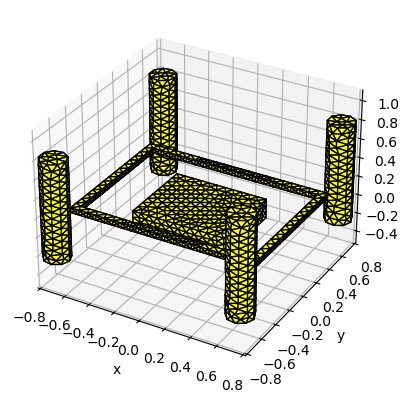

In [3]:
#with pygmsh.geo.Geometry() as geom:
#    platform = geom.add_box(-platformLength/2, platformLength/2, -platformWidth/2, platformWidth/2, 
#                       -platformHeight/2, platformHeight/2, mesh_size = 0.15)
#    platformMesh = geom.generate_mesh()

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.28)
    platform = geom.add_box([-platformFrameLength/2, -platformFrameWidth/2, -platformFrameTopDepth-platformFrameThickness], [platformFrameLength,platformFrameWidth,platformFrameThickness])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, -platformFrameTopDepth-platformFrameThickness], [cutoutLength,cutoutWidth,platformFrameThickness])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    DAQ = geom.add_box([-daqLength/2, -daqWidth/2, -daqTopDepth-daqHeight], [daqLength,daqWidth,daqHeight])
    platformFrame = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformFrame,DAQ,cyl1,cyl2,cyl3,cyl4])
    platformMesh = geom.generate_mesh()

fb = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=[0,0,0])
fb = fb.translate_z(-platformCG[2])
fb.show_matplotlib()

cpt.io.mesh_writers.write_STL('platform.stl',fb.mesh.vertices, fb.mesh.faces)

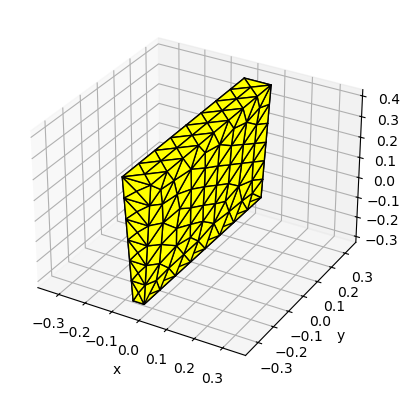

In [5]:
with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

fb = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap', center_of_mass=[0,0,0])
fb = fb.translate_x(-flap1CG[0])
fb = fb.translate_z(-flap1CG[2])
fb.show_matplotlib()

cpt.io.mesh_writers.write_STL('flap.stl',fb.mesh.vertices, fb.mesh.faces)